In [1341]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [1342]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [1343]:
X.isna().mean() * 100 

age               0.000000
workclass         1.971664
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        1.977806
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    0.560993
dtype: float64

In [1344]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


In [1345]:
X.value_counts()

age  workclass         fnlwgt  education     education-num  marital-status      occupation         relationship   race   sex     capital-gain  capital-loss  hours-per-week  native-country
25   Private           308144  Bachelors     13             Never-married       Craft-repair       Not-in-family  White  Male    0             0             40              Mexico            3
21   Private           243368  Preschool     1              Never-married       Farming-fishing    Not-in-family  White  Male    0             0             50              Mexico            3
25   Private           195994  1st-4th       2              Never-married       Priv-house-serv    Not-in-family  White  Female  0             0             40              Guatemala         3
43   Private           195258  HS-grad       9              Married-civ-spouse  Craft-repair       Husband        White  Male    0             0             40              United-States     2
30   Private           180317  Assoc-voc

In [1346]:
y.head()

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


In [1347]:
y.isna().mean() * 100

income    0.0
dtype: float64

In [1348]:
y.value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

In [1349]:
y = y.copy()
y['income'] = (
    y['income']
    .str.strip()
    .str.replace('.', '', regex=False)
)

y.value_counts()

income
<=50K     37155
>50K      11687
Name: count, dtype: int64

In [1350]:
y['less_than_50k'] = (y['income'] == '<=50K').astype(int)

In [1351]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   income         48842 non-null  object
 1   less_than_50k  48842 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 763.3+ KB


In [1352]:
y = y.drop(columns=['income'])

In [1353]:
y = y['less_than_50k']

# Target(y) is clean and ready. Now we can start cleaning Features(x). #

In [1354]:
X.columns = X.columns.str.replace('-', '_', regex=False)

In [1355]:
X.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [1356]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


In [1357]:
remove_na_rows = {
    'occupation', 'native_country'
}

for col in remove_na_rows:
    X = X.loc[X[col] != "?"] # Remove NA row

In [1358]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

binarizer_columns = {
    'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'native_country'
}

for col in binarizer_columns:
    X.loc[:, col] = (
        X[col]
        .fillna('')
        .str.lower()
        .apply(lambda s: [s] if s else [])
    )




encode_parts = []

for col in binarizer_columns:
    mlb = MultiLabelBinarizer()
    arr = mlb.fit_transform(X[col])

    encode_map = pd.DataFrame(
        arr,
        columns = [f'{col}__{cls}' for cls in mlb.classes_],
        index = X.index
    )

    encode_parts.append(encode_map)

X_encoded = pd.concat(encode_parts, axis=1)


X = pd.concat([X, X_encoded], axis=1)


X = X.copy()


X['is_male'] = (X['sex'] == 'Male').astype(int)


X = X.drop(columns=['sex', 'workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country', 'fnlwgt', 'capital_gain', 'capital_loss'])

X.head()

,age,education_num,hours_per_week,relationship__husband,relationship__not-in-family,relationship__other-relative,relationship__own-child,relationship__unmarried,relationship__wife,marital_status__divorced,...,native_country__trinadad&tobago,native_country__united-states,native_country__vietnam,native_country__yugoslavia,race__amer-indian-eskimo,race__asian-pac-islander,race__black,race__other,race__white,is_male
0,39,13,40,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
1,50,13,13,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
2,38,9,40,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,1,1
3,53,7,40,1,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1
4,28,13,40,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0


In [1359]:
X.isna().mean() * 100

age                            0.0
education_num                  0.0
hours_per_week                 0.0
relationship__husband          0.0
relationship__not-in-family    0.0
                              ... 
race__asian-pac-islander       0.0
race__black                    0.0
race__other                    0.0
race__white                    0.0
is_male                        0.0
Length: 85, dtype: float64

In [1360]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46443 entries, 0 to 48841
Data columns (total 85 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   age                                         46443 non-null  int64
 1   education_num                               46443 non-null  int64
 2   hours_per_week                              46443 non-null  int64
 3   relationship__husband                       46443 non-null  int64
 4   relationship__not-in-family                 46443 non-null  int64
 5   relationship__other-relative                46443 non-null  int64
 6   relationship__own-child                     46443 non-null  int64
 7   relationship__unmarried                     46443 non-null  int64
 8   relationship__wife                          46443 non-null  int64
 9   marital_status__divorced                    46443 non-null  int64
 10  marital_status__married-af-spouse      

In [1361]:
len(y)

48842

In [1362]:
len(X)

46443

In [1363]:
y = y.loc[X.index] # Re-aligning y with X after preprocessing. It can misaligned indices and silently corrupt training

# Features are now clean and we are ready to processed with the model. #

- Task: Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset.
- Type: Classification

In [1364]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numeric_cols = [
    'age',
    'education_num',
    'hours_per_week'
]

linear_preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough' 
)


In [1365]:
def linear_model(model):
    return (
        Pipeline([
            ('preprocess', linear_preprocess),
            ('model', model)
        ])
    )

def classification_metrics(y_true, y_pred, y_proba):
    return {
        'ROC-AUC': (roc_auc_score(y_true, y_proba)),
        'Accuracy' : (accuracy_score(y_true, y_pred)),
        'Precision' : (precision_score(y_true, y_pred)),
        'Recall' : (recall_score(y_true, y_pred))
    }

lg_pipe = linear_model(LogisticRegression(max_iter=1000))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lg_pipe.fit(X_train, y_train)
y_pred = lg_pipe.predict(X_test)
y_proba = lg_pipe.predict_proba(X_test)[:, 1]

classification_metrics(y_test, y_pred, y_proba)


{'ROC-AUC': 0.8896732448508928,
 'Accuracy': 0.8369038647863064,
 'Precision': 0.8661260303110875,
 'Recall': 0.9276662394987897}

In [1366]:
from xgboost import XGBClassifier

def non_linear_model(model):
    return (
        Pipeline([
            ('model', model)
        ])
    )

xg_pipe = non_linear_model(XGBClassifier(random_state=42, n_estimators=500, max_depth=4))
xg_pipe.fit(X_train, y_train)
xg_pred = xg_pipe.predict(X_test)
xg_proba = xg_pipe.predict_proba(X_test)[:, 1]

classification_metrics(y_test, xg_pred, xg_proba)

{'ROC-AUC': 0.8925477365443689,
 'Accuracy': 0.8416406502314565,
 'Precision': 0.8761517615176152,
 'Recall': 0.920689164174854}

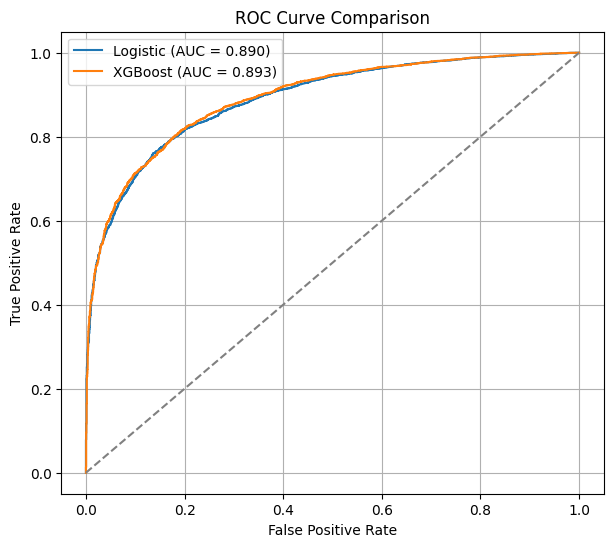

In [1367]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Logistic
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# XGBoost
fpr_xg, tpr_xg, _ = roc_curve(y_test, xg_proba)
roc_auc_xg = auc(fpr_xg, tpr_xg)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC = {roc_auc_lr:.3f})")
plt.plot(fpr_xg, tpr_xg, label=f"XGBoost (AUC = {roc_auc_xg:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

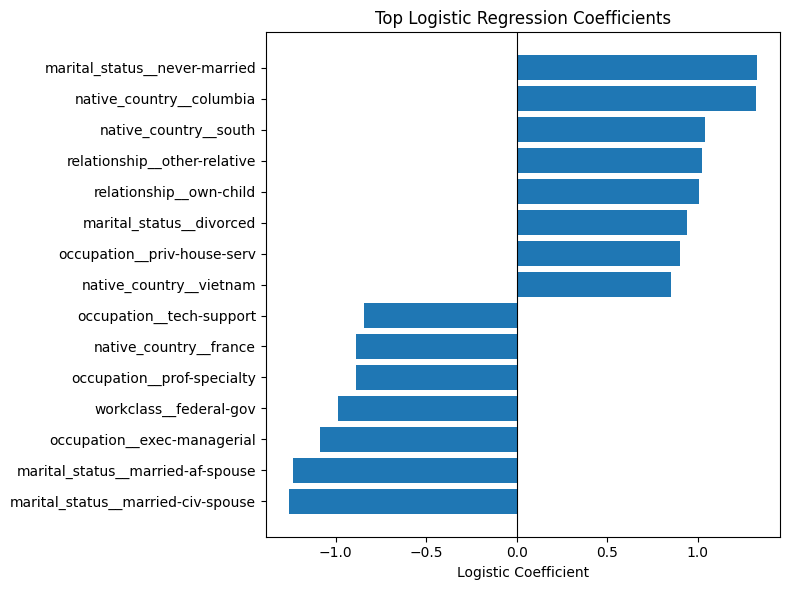

In [1368]:
# Get trained logistic model
log_model = lg_pipe.named_steps["model"]

# Getting feature names after preprocessing
feature_names = lg_pipe.named_steps["preprocess"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": log_model.coef_[0]
})

# Cleaning where we got the features
coef_df["feature"] = coef_df["feature"].str.replace("remainder__", "")

coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

top_n = 15
top_features = coef_df.head(top_n).sort_values("coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("Logistic Coefficient")
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

ROC curves show that Logistic Regression and XGBoost perform nearly identical, with only a marginal improvement from XGBoost. This suggests the underlying relationships in the Adult dataset are largely linear, making logistic regression a strong and interpretable choice overall.